#알약 객체 탐지 프로젝트: 데이터 전처리 및 EDA 파이프라인


##1. 환경 및 경로 설정

먼저 이미지 처리(PIL), 데이터 분석(pandas), 인코딩 감지(chardet)를 위한 라이브러리를 불러옵니다.

In [ ]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
import platform

import json
import shutil
import chardet
import re
from PIL import Image

# 기본 옵션 설정
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
sns.set_palette("Set2")
plt.rc('axes', unicode_minus=False)
%config InlineBackend.figure_format = 'retina'

# 한글 폰트 설정
system_name = platform.system()
if system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumBarunGothic')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
current_path = '/content/drive/My Drive/codeit/teamproject1'
if os.path.exists(current_path):
    print(f"The directory '{current_path}' exists.")
else:
    print(f"Error: The directory '{current_path}' does not exist. Please check the path.")

The directory '/content/drive/My Drive/codeit/teamproject1' exists.


In [ ]:
current_path = '/content/drive/My Drive/codeit/teamproject1'
os.chdir(current_path)
sys.path.append(current_path)


annotations_dir = Path('/content/drive/My Drive/codeit/teamproject1/train_annotations')
output_csv_path = Path('/content/drive/My Drive/codeit/teamproject1/image_annotations.csv')

In [ ]:
base_path = Path(r"/content/drive/My Drive/codeit/teamproject1")
train_img_dir = base_path / "train_images"
train_ann_dir = base_path / "train_annotations"
test_img_dir = base_path / "test_images"

# 작업용 통합 폴더 생성
work_img_dir = base_path / "processed" / "images"
work_ann_dir= base_path / "processed" / "annotations"
os.makedirs(work_img_dir, exist_ok=True)
os.makedirs(work_ann_dir, exist_ok=True)


##2. 이미지 데이터 정제
흩어진 이미지를 모으고, 손상된 파일을 제거하여 학습 중 에러를 방지
###2.1 이미지 파일 통합 및 복사


In [ ]:
def collect_images(source_dir, dest_dir):
    #PNG 파일을 수집하여 한 곳으로 복사 (index 포함 파일 제외)
    count = 0
    for root, _, files in os.walk(source_dir):
        for file in files:
            if file.lower().endswith(".png") and "index" not in file.lower():
                shutil.copy2(os.path.join(root, file), os.path.join(dest_dir, file))
                count += 1
    print(f" 이미지 수집 완료: {count}개 파일을 {dest_dir}로 복사했습니다.")

collect_images(train_img_dir, work_img_dir)


 이미지 수집 완료: 232개 파일을 /content/drive/My Drive/codeit/teamproject1/processed/images로 복사했습니다.


###2.2 손상된 이미지 검사 및 삭제

In [ ]:
def remove_corrupt_images(img_folder):
    """PIL을 이용해 깨진 이미지를 확인하고 삭제"""
    corrupt_list = []
    for file in os.listdir(img_folder):
        file_path = os.path.join(img_folder, file)
        try:
            with Image.open(file_path) as img:
                img.verify()
        except:
            print(f" 손상된 파일 삭제: {file}")
            os.remove(file_path)
            corrupt_list.append(file)
    return corrupt_list

remove_corrupt_images(work_img_dir)


[]

### 2.3 이미지 사이즈 및 해상도 확인

In [ ]:
import os
from PIL import Image
from collections import Counter
import pandas as pd

def check_image_resolutions(img_dir):
    resolutions = []

    # 폴더 내 이미지 파일 탐색
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"총 {len(img_files)}개의 이미지를 분석 중...")

    for file in img_files:
        img_path = os.path.join(img_dir, file)
        try:
            with Image.open(img_path) as img:
                # 가로, 세로 크기 추출
                width, height = img.size
                resolutions.append((width, height))
        except Exception as e:
            print(f" {file} 읽기 실패: {e}")

    # 1. 해상도별 빈도수 계산
    res_counts = Counter(resolutions)

    # 2. 결과 출력용 데이터프레임 생성
    res_df = pd.DataFrame([
        {'Width': res[0], 'Height': res[1], 'Count': count}
        for res, count in res_counts.items()
    ]).sort_values(by='Count', ascending=False)

    print("\n[이미지 해상도 통계]")
    print(res_df.to_string(index=False))

    # 모든 이미지 크기가 동일한지 확인
    if len(res_counts) == 1:
        print(f"\n 모든 이미지가 {resolutions[0][0]}x{resolutions[0][1]}로 동일합니다.")
    else:
        print(f"\n 주의: 서로 다른 해상도가 {len(res_counts)}종류 발견되었습니다.")

    return res_df

# 실행 (이미지가 수집된 작업 폴더 경로를 넣어주세요)
image_dir = work_img_dir
resolution_stats = check_image_resolutions(image_dir)


총 232개의 이미지를 분석 중...

[이미지 해상도 통계]
 Width  Height  Count
   976    1280    232

 모든 이미지가 976x1280로 동일합니다.


### 결과
* 총 232개의 이미지 해상도를 분석했습니다.

* 232개 이미지 모두 976x1280 픽셀의 균일한 해상도를 가진 것으로 나타났습니다.

### 연구 방향
* 이미지 해상도가 976x1280으로 균일하기 때문에, 다양한 이미지 크기를 처리할 필요가 없어 후속 처리 단계가 간소화되고, 잠재적으로 컴퓨팅 리소스와 개발 노력을 절감할 수 있습니다.

* 해상도가 일관적이므로, 다음 단계에서는 크기 조정이나 다양한 종횡비에 대한 복잡한 처리 없이 데이터 증강이나 모델 학습과 같은 이미지 처리 작업을 바로 진행할 수 있습니다.

##3. Annotation(JSON) 표준화

JSON 파일의 인코딩을 맞추고, image_id와 category_id를 모델이 인식 가능한 형태로 재구성합니다.

In [ ]:
from pathlib import Path

all_json_paths = list(train_ann_dir.glob('*_json/*/*.json'))
print(f"Found {len(all_json_paths)} JSON annotation files.")

Found 763 JSON annotation files.


In [ ]:
# 첫 번째 '_json' 폴더의 내용을 확인
json_subdirs = list(annotations_dir.glob('*_json'))

if json_subdirs:
    first_subdir = json_subdirs[0]
    print(f"Contents of '{first_subdir}':")
    for item in os.listdir(first_subdir):
        print(item)
else:
    print(f"'{annotations_dir}' 경로에 '_json'으로 끝나는 폴더가 없습니다.")

Contents of '/content/drive/My Drive/codeit/teamproject1/train_annotations/K-001900-016548-024850-029345_json':
K-001900
K-016548
K-029345
K-024850


In [ ]:
if os.path.exists(annotations_dir):
    print(f"Contents of '{annotations_dir}':")
    for item in os.listdir(annotations_dir):
        print(item)
else:
    print(f"'{annotations_dir}' 경로에 '_json'으로 끝나는 폴더가 없습니다.")

Contents of '/content/drive/My Drive/codeit/teamproject1/train_annotations':
K-001900-016548-024850-029345_json
K-001900-016548-019607-029451_json
K-001900-016548-021771-027926_json
K-001900-016548-019607-033009_json
K-001900-016551-029345-033208_json
K-002483-012081-012778-025438_json
K-002483-003743-012778-013395_json
K-003351-003832-016262_json
K-002483-019552-022362-025438_json
K-003351-003832-016232_json
K-003351-003832-016688_json
K-003351-003832-035206_json
K-003351-003832-029667_json
K-003351-003832-036637_json
K-003351-003832-021325_json
K-003351-003832-020238_json
K-003351-003832-022074_json
K-003351-003832-038162_json
K-003351-013900-020238_json
K-003351-013900-035206_json
K-003351-013900-021325_json
K-003351-013900-029667_json
K-003351-013900-022074_json
K-003351-013900-036637_json
K-003351-016262-031863_json
K-003351-016688-041768_json
K-003351-013900-038162_json
K-003351-018147-020238_json
K-003351-016232-033880_json
K-003351-016262-018147_json
K-003351-018357-020238_json

In [ ]:
def fix_and_standardize_json(ann_folder, start_id=1):
    file_id_map = {}
    current_id = start_id

    for file in os.listdir(ann_folder):
        if not file.endswith(".json"): continue
        file_path = os.path.join(ann_folder, file)

        # 1. 인코딩 감지 및 로드
        with open(file_path, "rb") as f:
            raw = f.read(10000)
            enc = chardet.detect(raw)['encoding']

        try:
            with open(file_path, "r", encoding=enc) as f:
                data = json.load(f)
        except:
            os.remove(file_path); continue

        # 2. 구조 업데이트 (Image ID 재할당)
        for img in data["images"]:
            f_name = img["file_name"]
            if f_name not in file_id_map:
                file_id_map[f_name] = current_id
                current_id += 1
            img["id"] = file_id_map[f_name]

            # Annotation의 image_id 동기화
            for ann in data["annotations"]:
                ann["image_id"] = img["id"]
                # dl_idx가 있다면 category_id로 강제 매핑
                if "dl_idx" in img:
                    ann["category_id"] = int(img["dl_idx"])

        # 3. 저장 (UTF-8 고정)
        with open(file_path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4, ensure_ascii=False)

fix_and_standardize_json(train_ann_dir)


In [ ]:
import json

# Initialize lists/sets to collect aggregated data
all_images = set() # Use a set to store unique image IDs
all_annotations = []
unique_categories = {} # Use a dictionary to store unique categories by ID

# Keep track of an example bounding box for display
example_bbox = None

print(f"Processing {len(all_json_paths)} JSON annotation files...")

# Iterate through each JSON file path
for json_path in all_json_paths:
    try:
        with open(json_path, 'r') as f:
            coco_data = json.load(f)

        # Aggregate image information
        for img_info in coco_data.get('images', []):
            all_images.add(img_info.get('id'))

        # Aggregate annotation information
        for annotation in coco_data.get('annotations', []):
            all_annotations.append(annotation)
            if example_bbox is None: # Store the first encountered bbox as an example
                example_bbox = annotation

        # Aggregate category information
        for category in coco_data.get('categories', []):
            if category.get('id') not in unique_categories:
                unique_categories[category.get('id')] = category.get('name')

    except Exception as e:
        print(f"Error processing file {json_path}: {e}")
        continue

# --- Summary of Aggregated Data ---
print("\n--- COCO JSON Annotation Summary ---")
print(f"Total unique images: {len(all_images)}")
print(f"Total annotations: {len(all_annotations)}")
print(f"Total unique categories: {len(unique_categories)}")

print("\nUnique Category Names (ID: Name):")
for cat_id, cat_name in unique_categories.items():
    print(f"  {cat_id}: {cat_name}")

if example_bbox:
    print("\nExample bounding box data (from first encountered annotation):")
    print(f"  Annotation ID: {example_bbox.get('id')}")
    print(f"  Image ID: {example_bbox.get('image_id')}")
    print(f"  Category ID: {example_bbox.get('category_id')}")
    print(f"  Bounding Box (x, y, width, height): {example_bbox.get('bbox')}")
    print(f"  Area: {example_bbox.get('area')}")
else:
    print("\nNo example bounding box data found.")

Processing 763 JSON annotation files...

--- COCO JSON Annotation Summary ---
Total unique images: 232
Total annotations: 763
Total unique categories: 56

Unique Category Names (ID: Name):
  1900: 보령부스파정 5mg
  16548: 가바토파정 100mg
  29345: 비모보정 500/20mg
  24850: 놀텍정 10mg
  29451: 레일라정
  19607: 스토가정 10mg
  21771: 라비에트정 20mg
  27926: 울트라셋이알서방정
  33009: 신바로정
  33208: 에스원엠프정 20mg
  16551: 동아가바펜틴정 800mg
  2483: 뮤테란캡슐 100mg
  12778: 다보타민큐정 10mg/병
  12081: 리렉스펜정 300mg/PTP
  25438: 큐시드정 31.5mg/PTP
  3743: 알드린정
  13395: 써스펜8시간이알서방정 650mg
  3351: 일양하이트린정 2mg
  16262: 크레스토정 20mg
  3832: 뉴로메드정(옥시라세탐)
  19552: 트루비타정 60mg/병
  22362: 맥시부펜이알정 300mg
  16232: 리피토정 20mg
  16688: 오마코연질캡슐(오메가-3-산에틸에스테르90)
  35206: 아토젯정 10/40mg
  29667: 리바로정 4mg
  36637: 로수젯정10/5밀리그램
  21325: 아토르바정 10mg
  20238: 플라빅스정 75mg
  22074: 리피로우정 20mg
  38162: 로수바미브정 10/20mg
  13900: 에빅사정(메만틴염산염)(비매품)
  31863: 아질렉트정(라사길린메실산염)
  41768: 카발린캡슐 25mg
  18147: 리리카캡슐 150mg
  33880: 글리틴정(콜린알포세레이트)
  18357: 종근당글리아티린연질캡슐(콜린알포세레이트) 
  19232: 콜리네

In [ ]:
import os
from pathlib import Path

# Specify the nested subdirectory to inspect
nested_subdir_path = Path('/content/drive/My Drive/codeit/teamproject1/train_annotations/K-003351-003832-038162_json/K-003832')

if nested_subdir_path.is_dir():
    print(f"Contents of '{nested_subdir_path}':")
    for item in os.listdir(nested_subdir_path):
        print(item)
else:
    print(f"'{nested_subdir_path}' 경로를 다시 확인해주세요.")

Contents of '/content/drive/My Drive/codeit/teamproject1/train_annotations/K-003351-003832-038162_json/K-003832':
K-003351-003832-038162_0_2_0_2_70_000_200.json
K-003351-003832-038162_0_2_0_2_75_000_200.json


중첩된 디렉터리 구조를 확인하고 샘플 JSON 파일을 식별했습니다.

샘플 JSON 파일 중 하나를 로드하여 내용을 검증하고 예상되는 키('images', 'annotations', 'categories')가 포함되어 있는지 확인합니다.


In [ ]:
import json
from pathlib import Path

# Path to a sample JSON file identified in the previous step
sample_json_path = Path('/content/drive/My Drive/codeit/teamproject1/train_annotations/K-003351-003832-038162_json/K-003832/K-003351-003832-038162_0_2_0_2_75_000_200.json')

if sample_json_path.is_file():
    with open(sample_json_path, 'r', encoding='utf-8') as f:
        sample_data = json.load(f)
    print(f"Keys in sample JSON file '{sample_json_path.name}': {sample_data.keys()}")
    # Further verification of content if needed
    print(f"'images' key present: {'images' in sample_data}")
    print(f"'annotations' key present: {'annotations' in sample_data}")
    print(f"'categories' key present: {'categories' in sample_data}")
else:
    print(f"Sample JSON file not found at '{sample_json_path}'. Please check the path.")

Keys in sample JSON file 'K-003351-003832-038162_0_2_0_2_75_000_200.json': dict_keys(['images', 'type', 'annotations', 'categories'])
'images' key present: True
'annotations' key present: True
'categories' key present: True


#### DataFrame 생성

* JSON 주석 파일은 `_json` 폴더 내의 하위 디렉토리, 구체적으로는 `/content/drive/My Drive/codeit/teamproject1/train_annotations/K-003351-003832-038162_json/K-003832/`와 같은 하위 디렉토리에 있습니다.

* 샘플 JSON 파일을 로드하여 'images', 'annotations', 'categories'와 같은 예상되는 최상위 키가 포함되어 있음을 확인했습니다.

* glob 패턴 `json_subdir.glob('*/.json')`에서 `json_subdir.glob('*/*.json')`로 수정하여 하위 디렉토리의 모든 어노테이션 파일에서 처리된 데이터가 포함된 `image_annotations.csv` 파일이 성공적으로 생성되었습니다.

#### 다음 단계
* `image_annotations.csv` 데이터프레임에 대한 추가 데이터 처리 또는 탐색적 데이터 분석(EDA)을 진행합니다.


##4. 최종 데이터셋 생성
데이터프레임 형태(CSV)로 변환하며, Train에만 있는 클래스를 고려하여 ID를 0부터 정렬해 재매핑합니다.


In [ ]:
# 각 JSON 파일 처리

all_rows = []
categories = {}

# 먼저 _json으로 끝나는 폴더들을 찾고, 그 안에 있는 .json 파일을 탐색
json_subdirs = list(annotations_dir.glob('*_json')) # _json으로 끝나는 모든 폴더를 찾음

if not json_subdirs:
    print(f"'{annotations_dir}' 경로에 '_json'으로 끝나는 폴더가 없습니다.")
else:
    print(f"'{annotations_dir}'에서 {len(json_subdirs)}개의 '_json' 폴더를 찾았습니다. 각 폴더 내 JSON 파일 처리 중")

    for json_subdir in json_subdirs:
        if json_subdir.is_dir(): # 실제로 디렉토리인지 확인
            # 수정: JSON 파일이 한 단계 더 깊은 서브디렉토리에 있으므로 glob 패턴을 변경합니다.
            # 기존: json_files_in_subdir = list(json_subdir.glob('*/.json'))
            json_files_in_subdir = list(json_subdir.glob('*/*.json')) # 해당 폴더 내의 하위 폴더에서 *.json 파일 찾기

            if not json_files_in_subdir:
                print(f"Warning: '{json_subdir}' 폴더의 하위 폴더 내에 JSON 파일이 없습니다. 건너뜁니다.")
                continue

            for json_file in json_files_in_subdir:
                try:
                    with open(json_file, 'r', encoding='utf-8') as f:
                        coco_data = json.load(f)

                    # 카테고리 매핑은 첫 파일에서만 로드하거나 모든 파일에서 통합
                    if not categories: # categories 딕셔너리가 비어있으면 초기화
                        if 'categories' in coco_data:
                            categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
                        else:
                            print(f"Warning: '{json_file}'에 categories 정보가 없습니다. 카테고리 매핑이 불완전할 수 있습니다.")

                    for ann in coco_data['annotations']:
                        # 해당 어노테이션의 이미지 정보 찾기
                        # 이미지 정보는 각 json 파일 내에 존재할 것으로 가정
                        img_info = next(img for img in coco_data['images'] if img['id'] == ann['image_id'])

                        # 이미지 파일명에서 숫자만 추출하여 image_id로 사용
                        img_filename = img_info['file_name']
                        # 파일명에서 확장자를 제거하고, 전체 문자열에서 숫자만 추출하여 사용
                        img_numeric_id_str = re.sub(r'[^0-9]', '', Path(img_filename).stem)
                        # img_numeric_id가 빈 문자열일 경우를 대비하여 기본값 설정
                        img_numeric_id = int(img_numeric_id_str) if img_numeric_id_str else 0

                        all_rows.append({
                            'annotation_id': len(all_rows) + 1,  # 고유 ID를 계속 증가
                            'image_id': img_numeric_id,
                            'category_id': ann['category_id'],
                            'category_name': categories.get(ann['category_id'], 'N/A'),
                            'bbox_x': ann['bbox'][0],
                            'bbox_y': ann['bbox'][1],
                            'bbox_w': ann['bbox'][2],
                            'bbox_h': ann['bbox'][3],
                            'score': ann.get('score', 1.0)
                        })
                except Exception as e:
                    print(f"Error processing {json_file}: {e}")
        else:
            print(f"Skipping non-directory item in train_annotations: {json_subdir}")

    if all_rows:
        df_annotations = pd.DataFrame(all_rows)
        df_annotations.to_csv(output_csv_path, index=False)
        print(f"'image_annotations.csv' 파일이 '{output_csv_path}'에 성공적으로 생성되었습니다.")
        print(df_annotations.head())
    else:
        print("처리할 어노테이션 데이터가 없습니다.")

'/content/drive/My Drive/codeit/teamproject1/train_annotations'에서 114개의 '_json' 폴더를 찾았습니다. 각 폴더 내 JSON 파일 처리 중
'image_annotations.csv' 파일이 '/content/drive/My Drive/codeit/teamproject1/image_annotations.csv'에 성공적으로 생성되었습니다.
   annotation_id                            image_id  category_id  \
0              1  1900016548024850029345020290000200         1900   
1              2  1900016548024850029345020270000200         1900   
2              3  1900016548024850029345020275000200         1900   
3              4  1900016548024850029345020275000200        16548   
4              5  1900016548024850029345020290000200        16548   

  category_name  bbox_x  bbox_y  bbox_w  bbox_h  score  
0    보령부스파정 5mg     182     266     130     200    1.0  
1    보령부스파정 5mg     685     807     131     211    1.0  
2    보령부스파정 5mg     161     257     129     201    1.0  
3           N/A     599     212     227     225    1.0  
4           N/A     623     220     237     226    1.0  


### COCO JSON 데이터 분석결과

* 총 232개의 고유 이미지

* 총 763개의 주석

* 총 56개의 고유 카테고리

* 어노테이션에서 추출된 바운딩 박스에는 ID, 이미지 ID, 카테고리 ID, 바운딩 박스 좌표 및 면적이 포함되어, 어노테이션 세부 정보가 정확하게 파싱되었음을 보여줍니다.

* 식별된 고유 카테고리와 그 개수는 잠재적인 클래스 불균형에 대한 판단과 필요한 경우 데이터 증강 또는 재샘플링 전략 수립으로 모델 학습 및 평가에 도움이 될 수 있습니다.

In [ ]:
def finalize_to_csv(ann_folder):
    all_data = []
    for file_path in ann_folder.glob('*_json/*/*.json'):
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            for ann in data['annotations']:
                img_info = next(i for i in data['images'] if i['id'] == ann['image_id'])
                # 파일명에서 숫자 ID 추출 (요구사항)
                img_numeric_id_str = re.sub(r'[^0-9]', '', Path(img_info['file_name']).stem)
                # img_numeric_id가 빈 문자열일 경우를 대비하여 기본값 설정
                num_id = int(img_numeric_id_str) if img_numeric_id_str else 0

                all_data.append({
                    'image_id': num_id,
                    'file_name': img_info['file_name'],
                    'category_id': ann['category_id'],
                    'bbox_x': ann['bbox'][0],
                    'bbox_y': ann['bbox'][1],
                    'bbox_w': ann['bbox'][2],
                    'bbox_h': ann['bbox'][3]
                })

    df = pd.DataFrame(all_data)

    # [중요] category_id를 0부터 연속된 숫자로 재매핑
    unique_cats = sorted(df['category_id'].unique())
    cat_map = {old: new for new, old in enumerate(unique_cats)}
    df['category_id'] = df['category_id'].map(cat_map)

    return df, cat_map

final_df, category_mapping = finalize_to_csv(train_ann_dir)
final_df.to_csv(base_path / "final_train_annotations.csv", index=False)
print(" 전처리 완료! final_train_annotations.csv 생성")

 전처리 완료! final_train_annotations.csv 생성


### 분석 결과
* `finalize_to_csv` 함수는 모든 관련 JSON 파일을 성공적으로 처리하고 이미지 및 주석 세부 정보(이미지 ID, 파일 이름, 카테고리 ID, 바운딩 박스 좌표)를 추출했습니다.

* `category_id` 값은 데이터셋에서 발견된 고유 카테고리를 기반으로 0부터 시작하는 연속적인 시퀀스로 재매핑되었습니다.

* 처리된 어노테이션이 포함된 DataFrame(`final_df`)이 성공적으로 생성되어 `final_train_annotations.csv` 파일로 저장되었으며, 출력 메시지는 "전처리 완료! final_train_annotations.csv가 생성되었습니다."입니다.

### 인사이트
* 개선된 데이터 로딩 프로세스는 어노테이션 파일의 다양한 디렉터리 구조를 안정적으로 처리할 수 있도록 보장하며, 이는 확장 가능한 데이터 파이프라인에 매우 중요합니다.

* `category_id` 값의 재매핑은 카테고리 레이블에 표준화된 연속적인 범위를 제공함으로써 후속 머신러닝 작업을 간소화합니다.


In [ ]:
df_final_annotations.head()

,image_id,file_name,category_id,bbox_x,bbox_y,bbox_w,bbox_h
0,1900016548024850029345020290000200,K-001900-016548-024850-029345_0_2_0_2_90_000_2...,0,182,266,130,200
1,1900016548024850029345020270000200,K-001900-016548-024850-029345_0_2_0_2_70_000_2...,0,685,807,131,211
2,1900016548024850029345020275000200,K-001900-016548-024850-029345_0_2_0_2_75_000_2...,0,161,257,129,201
3,1900016548024850029345020275000200,K-001900-016548-024850-029345_0_2_0_2_75_000_2...,15,599,212,227,225
4,1900016548024850029345020290000200,K-001900-016548-024850-029345_0_2_0_2_90_000_2...,15,623,220,237,226


In [ ]:
df_final_annotations, category_mapping = finalize_to_csv(train_ann_dir)
print(df_final_annotations.head())
print(f"Number of unique categories after remapping: {len(category_mapping)}")

                             image_id  \
0  1900016548024850029345020290000200   
1  1900016548024850029345020270000200   
2  1900016548024850029345020275000200   
3  1900016548024850029345020275000200   
4  1900016548024850029345020290000200   

                                           file_name  category_id  bbox_x  \
0  K-001900-016548-024850-029345_0_2_0_2_90_000_2...            0     182   
1  K-001900-016548-024850-029345_0_2_0_2_70_000_2...            0     685   
2  K-001900-016548-024850-029345_0_2_0_2_75_000_2...            0     161   
3  K-001900-016548-024850-029345_0_2_0_2_75_000_2...           15     599   
4  K-001900-016548-024850-029345_0_2_0_2_90_000_2...           15     623   

   bbox_y  bbox_w  bbox_h  
0     266     130     200  
1     807     131     211  
2     257     129     201  
3     212     227     225  
4     220     237     226  
Number of unique categories after remapping: 56


### 분석 결과

1. Test Set 클래스 불일치:

    여기에서 생성된 category_mapping을 보관해두었다가, Test 데이터를 예측할 때 동일한 ID를 적용해야 합니다.

2. 클래스 개수:

    len(category_mapping)을 통해 전체 클래스 개수를 확인해 모델 설정(YAML)에 반영

3. 데이터 무결성:

    이미지 파일이 없는 JSON은 remove_invalid_json 로직(이전 단계)을 통해 걸러진 후 이 과정을 진행하는 것이 안전합니다.

4. image_id 문제:

    파일명에서 숫자를 모두 추출하다 보니 ID가 너무 길어져서 가독성이 떨어지고 처리가 무겁습니다.

5. 데이터 구조:
    한 이미지(image_id) 안에 여러 개의 category_id(객체)가 있는 Multi-Object 형태입니다.


##5. 시각화 (클래스 분포 및 박스 크기)

학습 데이터의 클래스 불균형이 있는지, 알약의 크기가 적절한지 확인합니다.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


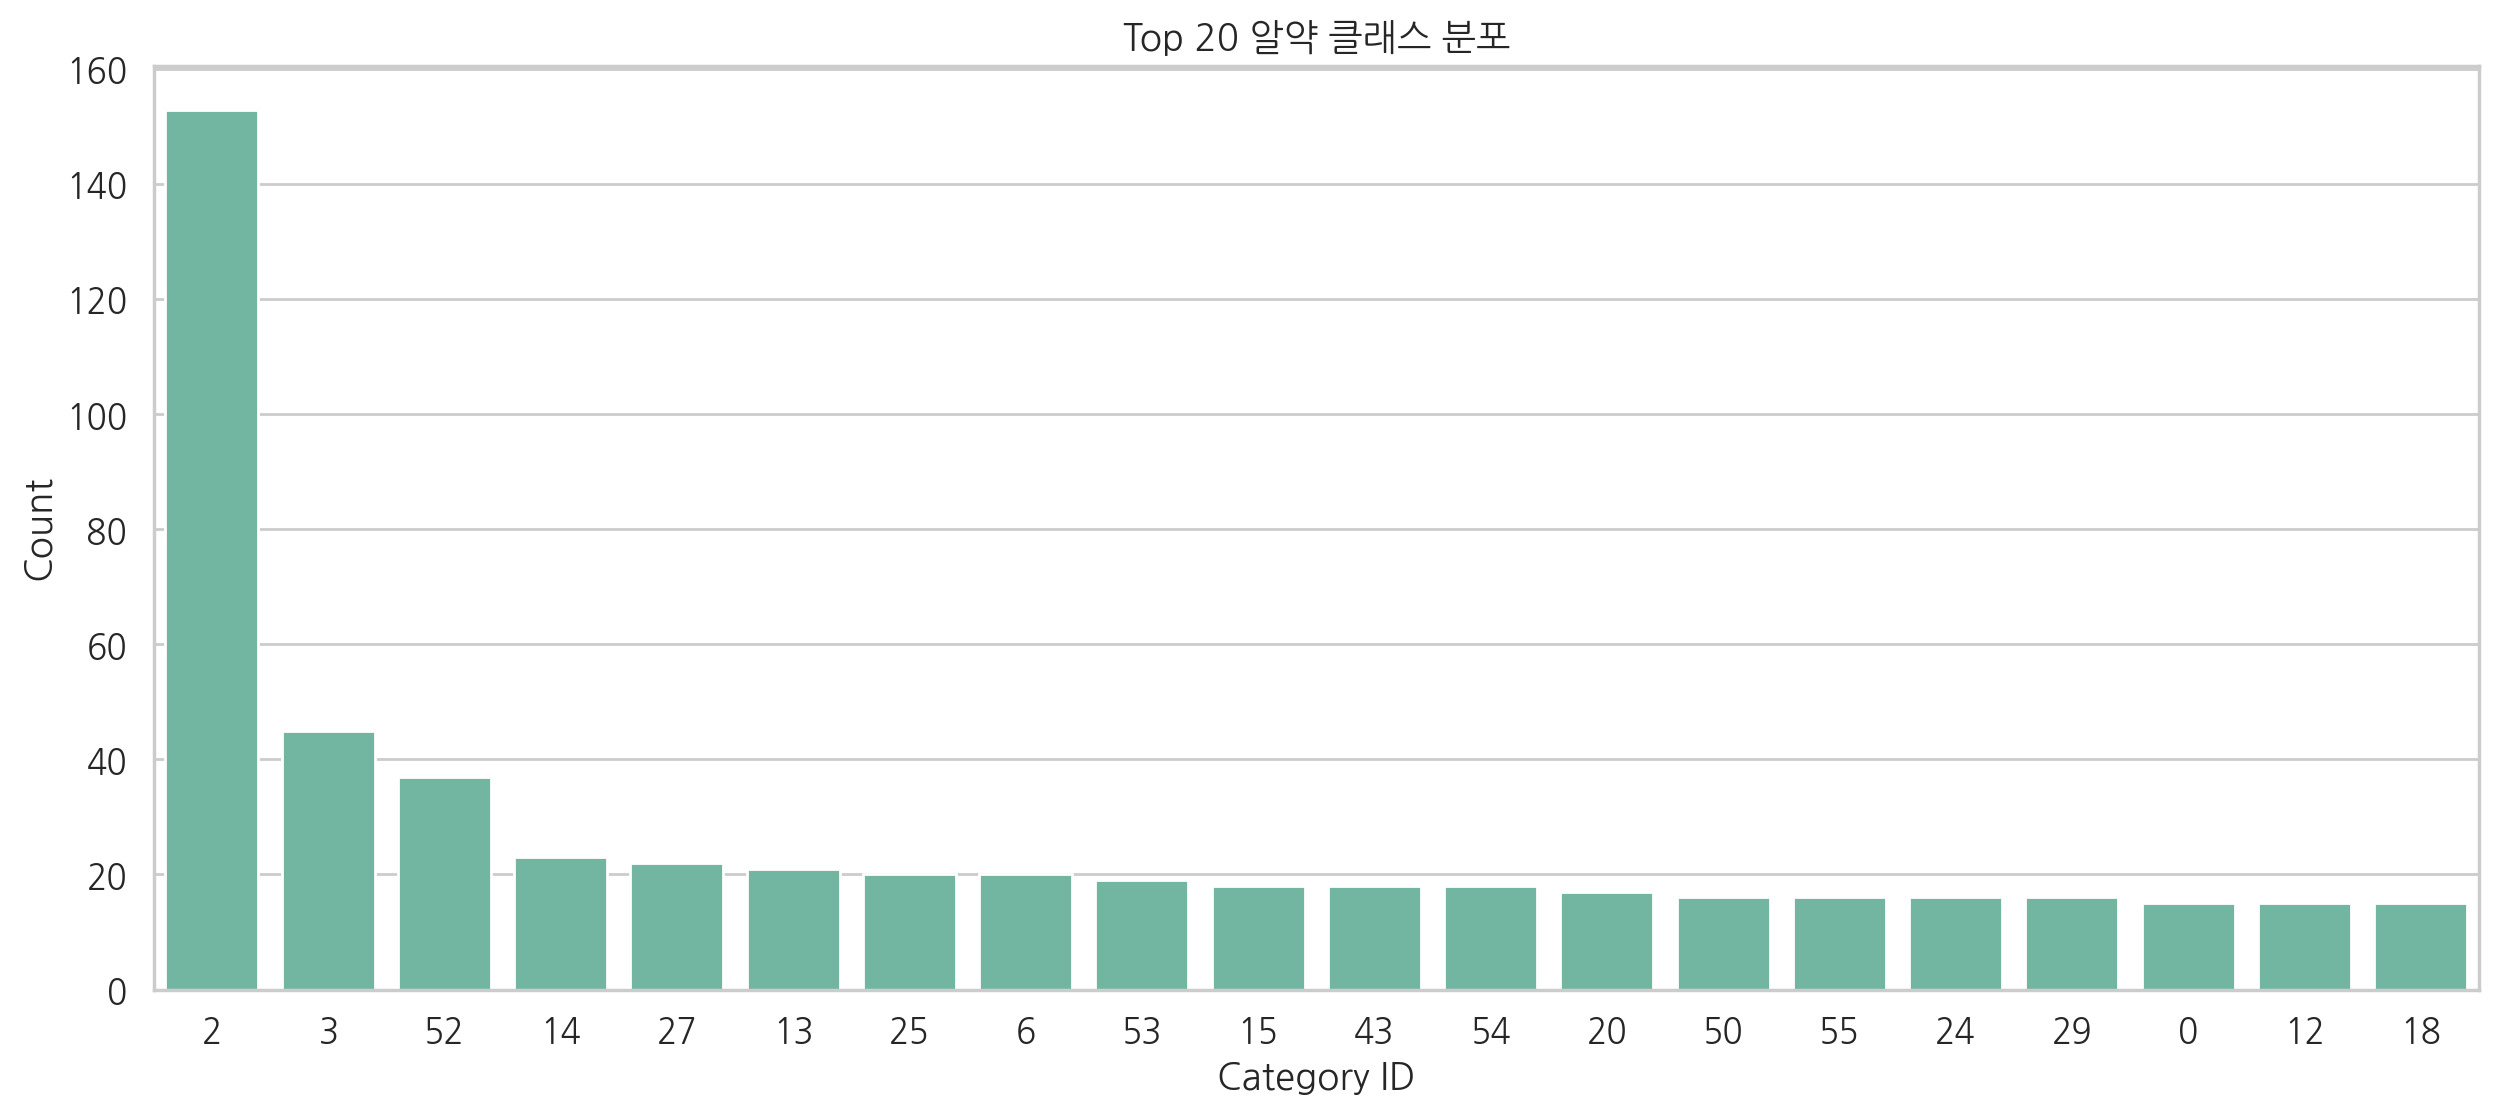

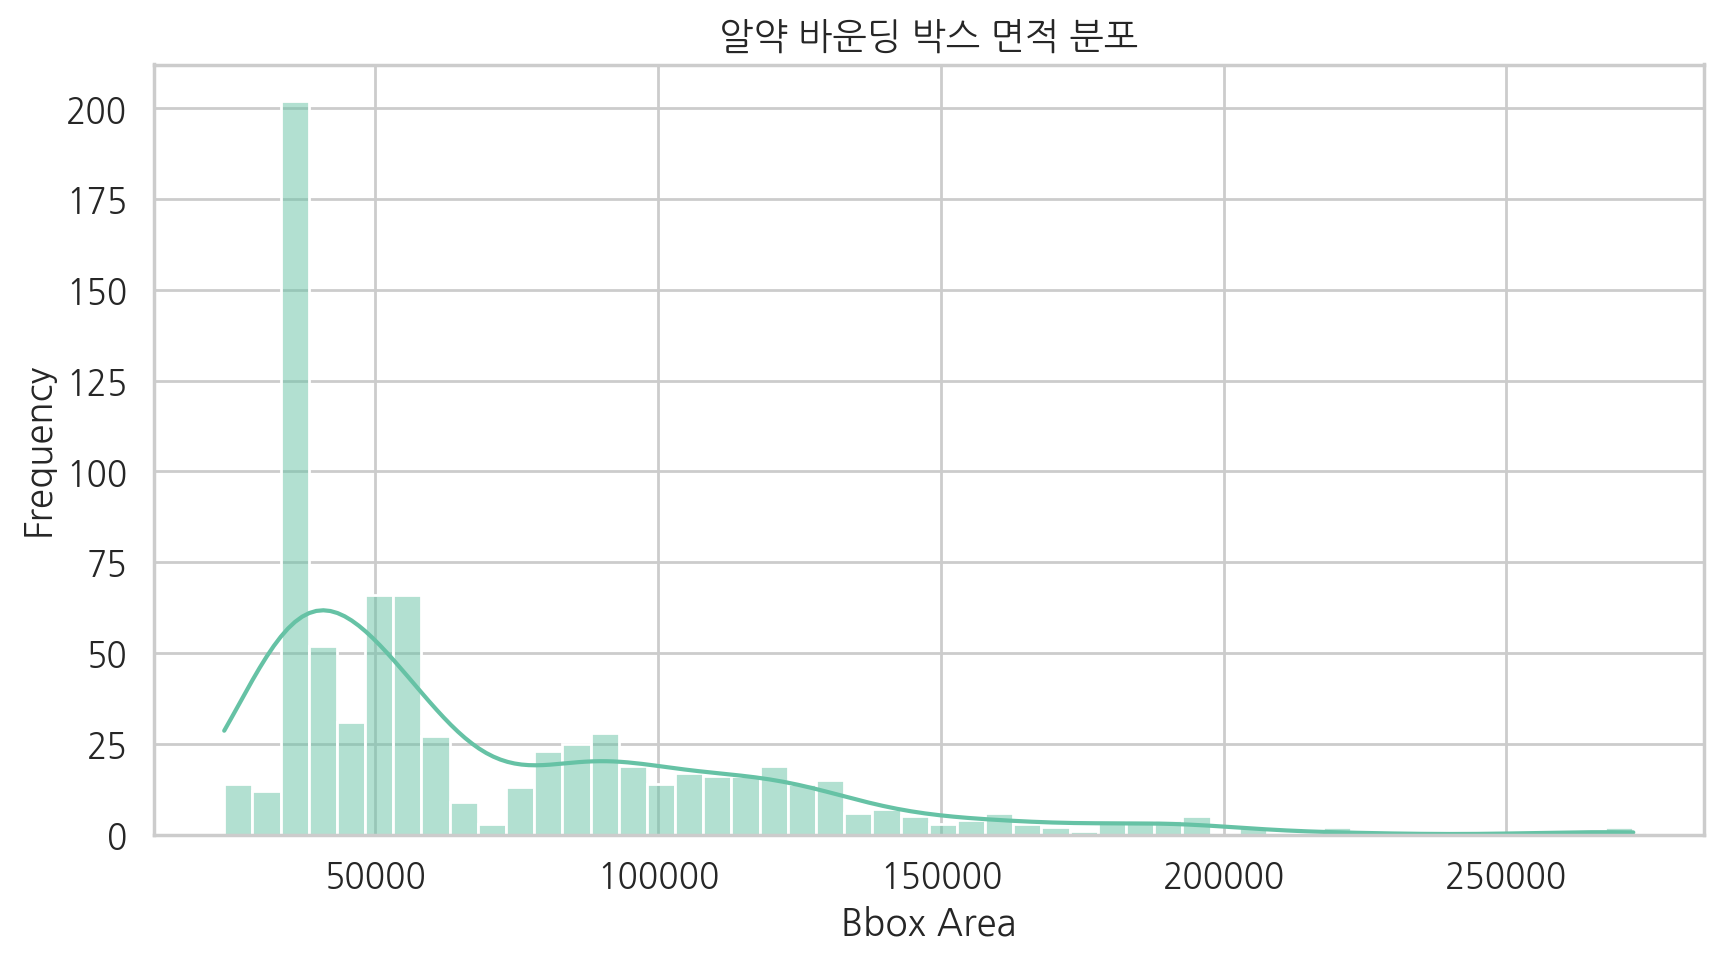

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 1. Nanum Gothic 폰트 설치
!apt-get update -qq
!apt-get install -qq fonts-nanum

# 2. 폰트 캐시 재생성 및 설정
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'})

# 3. EDA Plots 다시 생성
# 1. 클래스별 빈도수 확인 (Top 20)
plt.figure(figsize=(15, 6))
sns.countplot(data=df_final_annotations, x='category_id', order=df_final_annotations['category_id'].value_counts().index[:20])
plt.title("Top 20 알약 클래스 분포")
plt.xlabel("Category ID")
plt.ylabel("Count")
plt.show()

# 2. 바운딩 박스 크기(Area) 분포 확인
df_final_annotations['area'] = df_final_annotations['bbox_w'] * df_final_annotations['bbox_h']
plt.figure(figsize=(10, 5))
sns.histplot(data=df_final_annotations, x='area', bins=50, kde=True)
plt.title("알약 바운딩 박스 면적 분포")
plt.xlabel("Bbox Area")
plt.ylabel("Frequency")
plt.show()

##6. YOLO 학습을 위한 좌표 정규화

- YOLO 모델은 픽셀 좌표가 아닌 0~1 사이의 상대 좌표를 사용

- 이미지의 가로/세로 크기(W, H) 정보가 필요합니다.

In [ ]:
def normalize_bbox(df, img_width=970, img_height=1100): # 실제 이미지 크기에 맞게 수정
    """픽셀 좌표 [x, y, w, h]를 YOLO 포맷 [x_center, y_center, w, h] (0~1)로 변환"""

    # x_center, y_center 계산
    df['x_center'] = (df['bbox_x'] + (df['bbox_w'] / 2)) / img_width
    df['y_center'] = (df['bbox_y'] + (df['bbox_h'] / 2)) / img_height

    # 너비와 높이 정규화
    df['norm_w'] = df['bbox_w'] / img_width
    df['norm_h'] = df['bbox_h'] / img_height

    return df

# 실제 이미지의 Width, Height를 입력하세요 (예: 1024, 1024)
final_df = normalize_bbox(final_df, img_width=1024, img_height=1024)
print("정규화 완료")
print(final_df[['category_id', 'x_center', 'y_center', 'norm_w', 'norm_h']].head())


정규화 완료
   category_id  x_center  y_center    norm_w    norm_h
0            0  0.241211  0.357422  0.126953  0.195312
1            0  0.732910  0.891113  0.127930  0.206055
2            0  0.220215  0.349121  0.125977  0.196289
3           15  0.695801  0.316895  0.221680  0.219727
4           15  0.724121  0.325195  0.231445  0.220703
